In [1]:
#Import Libraries 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#read the data 
df = pd.read_csv('employees_dataset.csv')
df

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,8724,Technology,region_26,Bachelors,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelors,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelors,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17412,64573,Technology,region_7,Bachelors,f,referred,2,30,5.0,6,1,0,81
17413,49584,HR,region_7,Bachelors,m,other,1,33,1.0,9,0,0,51
17414,49584,HR,region_7,Bachelors,m,other,1,33,1.0,9,0,0,51
17415,49584,HR,region_7,Bachelors,m,other,1,33,1.0,9,0,0,51


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17417 entries, 0 to 17416
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   employee_id            17417 non-null  int64  
 1   department             17417 non-null  object 
 2   region                 17417 non-null  object 
 3   education              16646 non-null  object 
 4   gender                 17417 non-null  object 
 5   recruitment_channel    17417 non-null  object 
 6   no_of_trainings        17417 non-null  int64  
 7   age                    17417 non-null  int64  
 8   previous_year_rating   16054 non-null  float64
 9   length_of_service      17417 non-null  int64  
 10  KPIs_met_more_than_80  17417 non-null  int64  
 11  awards_won             17417 non-null  int64  
 12  avg_training_score     17417 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 1.7+ MB


In [ ]:
df.duplicated().sum() #Duplicates

np.int64(2)

In [ ]:
df.isnull().sum() #Null values in the dataset

employee_id                 0
department                  0
region                      0
education                 771
gender                      0
recruitment_channel         0
no_of_trainings             0
age                         0
previous_year_rating     1363
length_of_service           0
KPIs_met_more_than_80       0
awards_won                  0
avg_training_score          0
dtype: int64

In [7]:
df['department'].value_counts() #Department distribution

department
Sales & Marketing    5458
Operations           3524
Procurement          2240
Technology           2199
Analytics            1697
HR                    833
Finance               802
Legal                 332
R&D                   332
Name: count, dtype: int64

In [8]:
df['region'].unique()

array(['region_26', 'region_4', 'region_13', 'region_2', 'region_29',
       'region_7', 'region_22', 'region_16', 'region_17', 'region_24',
       'region_11', 'region_27', 'region_9', 'region_20', 'region_34',
       'region_23', 'region_8', 'region_14', 'region_31', 'region_19',
       'region_5', 'region_28', 'region_15', 'region_3', 'region_25',
       'region_12', 'region_21', 'region_30', 'region_10', 'region_33',
       'region_32', 'region_6', 'region_1', 'region_18'], dtype=object)

In [9]:
df['education'].unique()

array(['Bachelors', 'Masters & above', nan, 'Below Secondary'],
      dtype=object)

In [10]:
df['education'].value_counts()

education
Bachelors          11519
Masters & above     4841
Below Secondary      286
Name: count, dtype: int64

In [11]:
df['gender'].unique()

array(['m', 'f'], dtype=object)

In [12]:
df['gender'].value_counts()

gender
m    12314
f     5103
Name: count, dtype: int64

In [13]:
df['recruitment_channel'].unique()

array(['sourcing', 'other', 'referred'], dtype=object)

In [14]:
df['recruitment_channel'].value_counts()

recruitment_channel
other       9751
sourcing    7349
referred     317
Name: count, dtype: int64

# Missing value percentage

In [15]:
missing_percent = (df.isnull().sum()/len(df))*100
missing_percent

employee_id              0.000000
department               0.000000
region                   0.000000
education                4.426710
gender                   0.000000
recruitment_channel      0.000000
no_of_trainings          0.000000
age                      0.000000
previous_year_rating     7.825688
length_of_service        0.000000
KPIs_met_more_than_80    0.000000
awards_won               0.000000
avg_training_score       0.000000
dtype: float64

## Education
#### Missing values: 771
#### Percentage missing: 4.43%
#### Missing percentage is relatively small.
#### Can be imputed using the mode (most frequent category).

In [16]:
df.duplicated().sum()

np.int64(2)

In [18]:
#2 duplicates in the dataset. We can drop them.
df.drop_duplicates(inplace=True)

In [19]:
df['education'].fillna(
df['education'].mode()[0],
inplace=True
)

C:\Users\golla\AppData\Local\Temp\ipykernel_4072\3025124388.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['education'].fillna(


## Previous Year Rating
#### Missing values: 1363
#### Percentage missing: 7.83%
#### Since ratings are ordinal numerical values (1–5), median imputation is suitable.

In [20]:
df['previous_year_rating'].unique()

array([nan,  3.,  1.,  2.,  4.,  5.])

In [21]:
df['previous_year_rating'].fillna(
df['previous_year_rating'].median(),
inplace=True
)

C:\Users\golla\AppData\Local\Temp\ipykernel_4072\3435762252.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['previous_year_rating'].fillna(


In [22]:
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
count,17415.000000,17415.000000,17415.000000,17415.000000,17415.000000,17415.000000,17415.000000,17415.000000
mean,39082.285214,1.250761,34.807982,3.318691,5.801493,0.358886,0.023371,63.177720
std,22708.049139,0.595720,7.694464,1.218216,4.175632,0.479687,0.151082,13.418314
min,3.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000
25%,19280.500000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000
50%,39115.000000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000
75%,58838.500000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,75.000000
max,78295.000000,9.000000,60.000000,5.000000,34.000000,1.000000,1.000000,99.000000


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17415 entries, 0 to 17416
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   employee_id            17415 non-null  int64  
 1   department             17415 non-null  object 
 2   region                 17415 non-null  object 
 3   education              17415 non-null  object 
 4   gender                 17415 non-null  object 
 5   recruitment_channel    17415 non-null  object 
 6   no_of_trainings        17415 non-null  int64  
 7   age                    17415 non-null  int64  
 8   previous_year_rating   17415 non-null  float64
 9   length_of_service      17415 non-null  int64  
 10  KPIs_met_more_than_80  17415 non-null  int64  
 11  awards_won             17415 non-null  int64  
 12  avg_training_score     17415 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 1.9+ MB


In [ ]:
df.isnull().sum() #Null values are removed

employee_id              0
department               0
region                   0
education                0
gender                   0
recruitment_channel      0
no_of_trainings          0
age                      0
previous_year_rating     0
length_of_service        0
KPIs_met_more_than_80    0
awards_won               0
avg_training_score       0
dtype: int64

In [ ]:
df.duplicated().sum() #Duplicates are removed

np.int64(0)

In [26]:
df[df.duplicated()]

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score


# Exploratory Data Analysis

#### Age Distribution

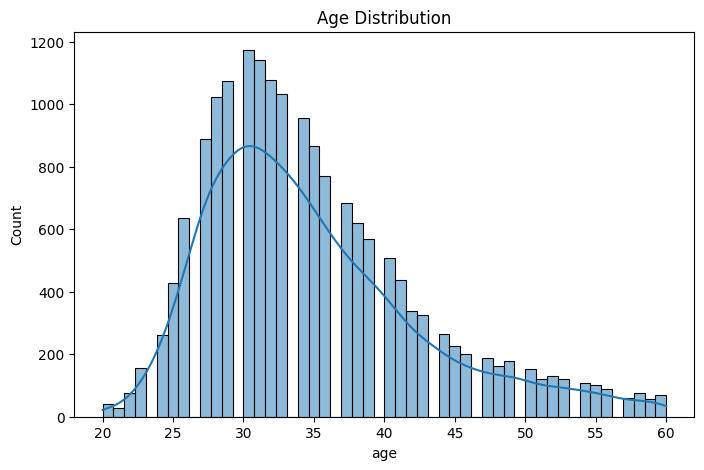

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

# Gender Distribution Analysis

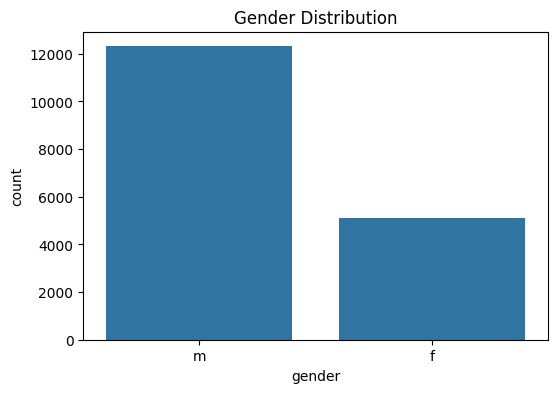

In [28]:
#Displays the count of male and female employees.
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)

plt.title("Gender Distribution")

plt.show()

# Education Distribution Analysis

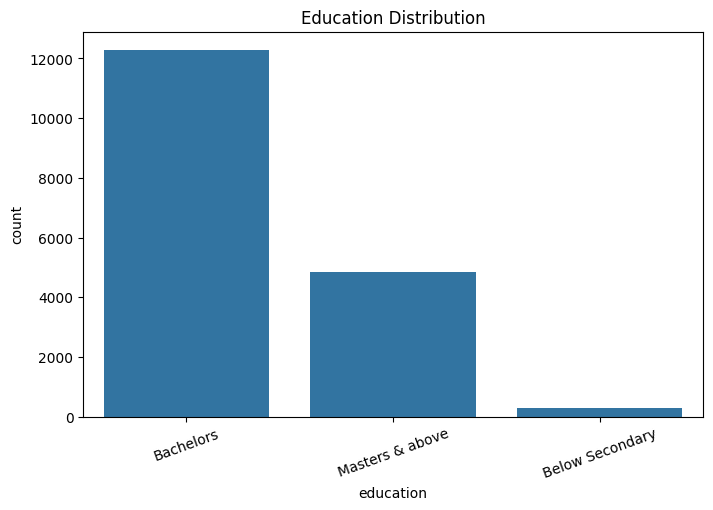

In [29]:
#Shows employee count by education level.
plt.figure(figsize=(8,5))

sns.countplot(
x='education',
data=df
)

plt.title("Education Distribution")

plt.xticks(rotation=20)

plt.show()

# Department Distribution Analysis

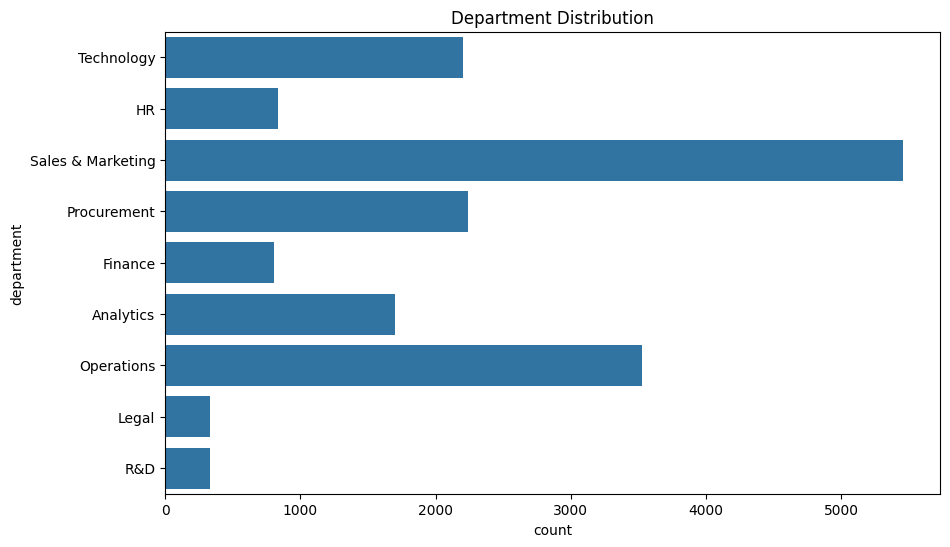

In [30]:
#Displays the number of employees in each department.
plt.figure(figsize=(10,6))

sns.countplot(
y='department',
data=df
)

plt.title("Department Distribution")

plt.show()

# Recruitment Channel Analysis

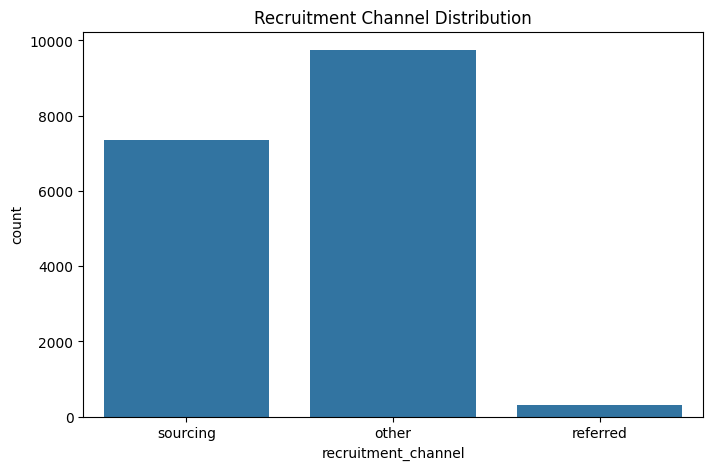

In [31]:
#Shows how employees were recruited.
plt.figure(figsize=(8,5))

sns.countplot(
x='recruitment_channel',
data=df
)

plt.title("Recruitment Channel Distribution")

plt.show()

# Number of Trainings Analysis

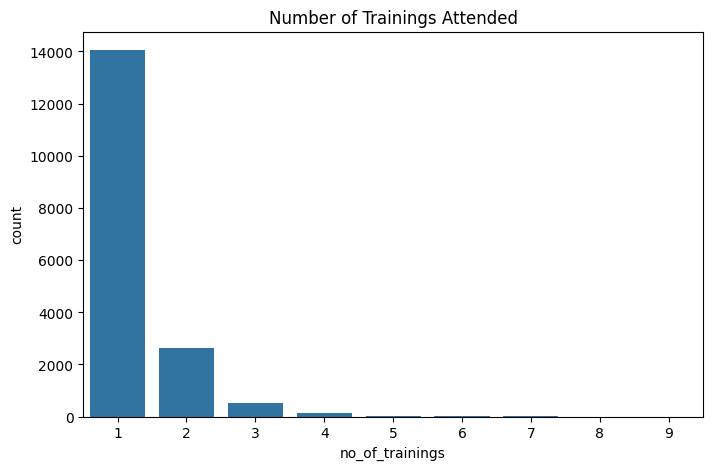

In [32]:
#Shows the frequency of training participation.
plt.figure(figsize=(8,5))

sns.countplot(
x='no_of_trainings',
data=df
)

plt.title("Number of Trainings Attended")

plt.show()

# Average Training Score Distribution

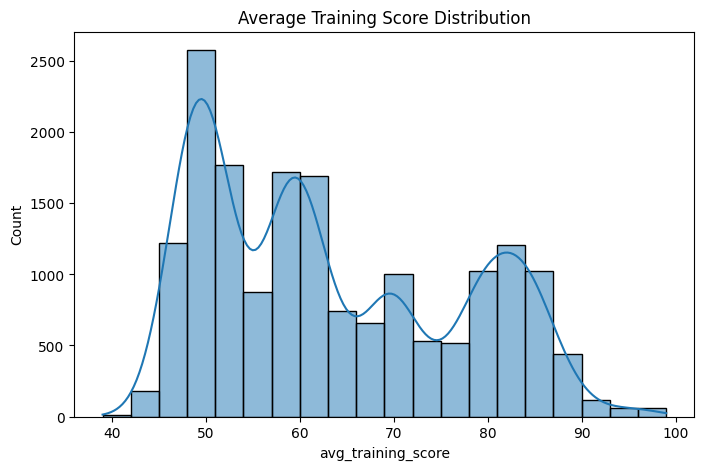

In [33]:
#Displays distribution of training scores.
plt.figure(figsize=(8,5))

sns.histplot(
df['avg_training_score'],
bins=20,
kde=True
)

plt.title("Average Training Score Distribution")

plt.show()

# Interpretation
#### Provides insight into overall employee performance levels.

# Length of Service Analysis

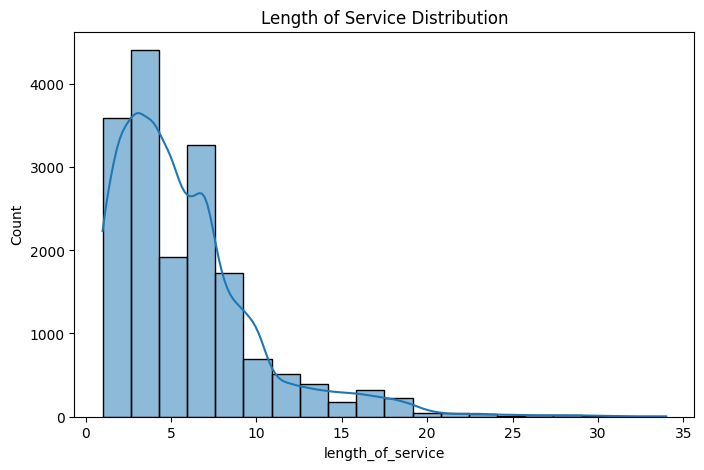

In [34]:
#Displays employee service duration.
plt.figure(figsize=(8,5))

sns.histplot(
df['length_of_service'],
bins=20,
kde=True
)

plt.title("Length of Service Distribution")

plt.show()

## Interpretation
#### Indicates retention patterns.
#### Identifies workforce stability.

# KPI Achievement Analysis

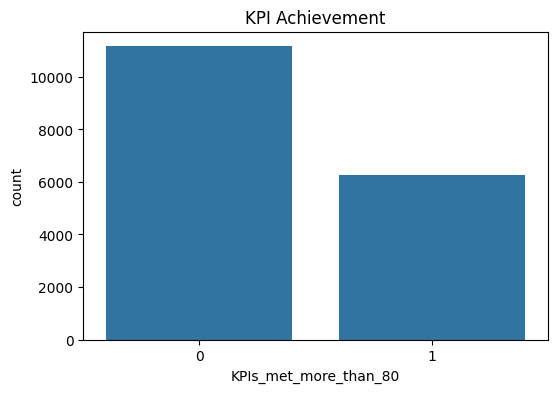

In [35]:
#Shows employees who achieved more than 80% KPIs versus those who did not.
plt.figure(figsize=(6,4))

sns.countplot(
x='KPIs_met_more_than_80',
data=df
)

plt.title("KPI Achievement")

plt.show()

## Interpretation
#### Helps evaluate organizational performance effectiveness.

# Awards Won Analysis

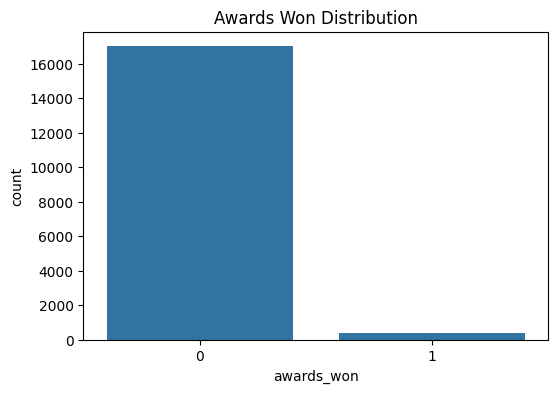

In [36]:
#Shows the number of employees who received awards.
plt.figure(figsize=(6,4))

sns.countplot(
x='awards_won',
data=df
)

plt.title("Awards Won Distribution")

plt.show()

## Interpretation
#### Indicates effectiveness of employee recognition programs.

# Region Distribution Analysis

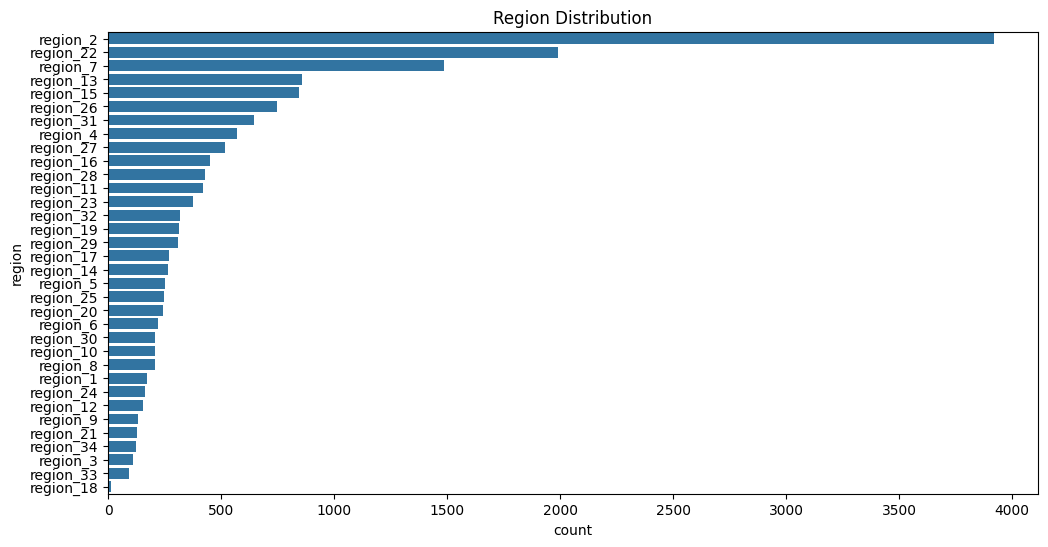

In [37]:
plt.figure(figsize=(12,6))

sns.countplot(
y='region',
data=df,
order=df['region'].value_counts().index
)

plt.title("Region Distribution")

plt.show()

# Training Score Distribution

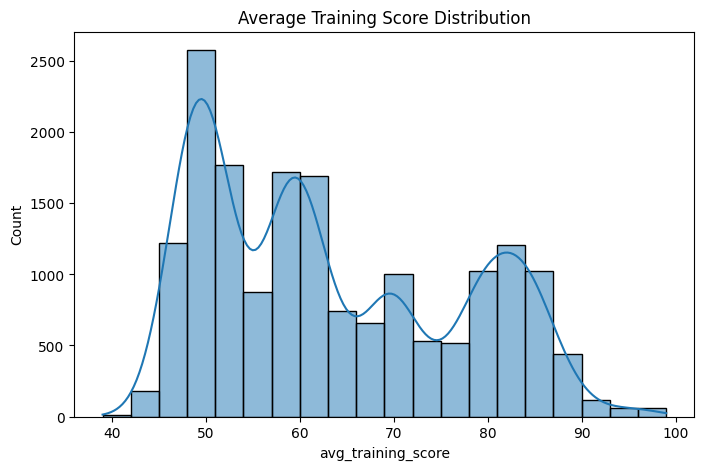

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(
df['avg_training_score'],
bins=20,
kde=True
)

plt.title('Average Training Score Distribution')

plt.show()

# KPI Percentage Visualization

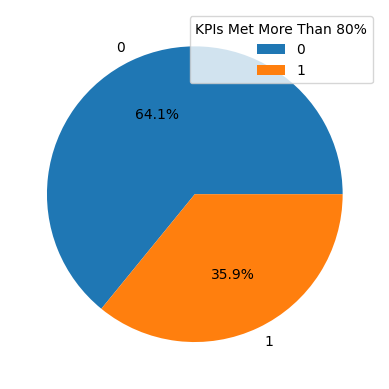

In [40]:
kpi = df['KPIs_met_more_than_80'].value_counts()

kpi.plot(
kind='pie',
autopct='%1.1f%%'
)

plt.ylabel('')
plt.legend(title='KPIs Met More Than 80%')
plt.show()

# Department-wise Training Scores

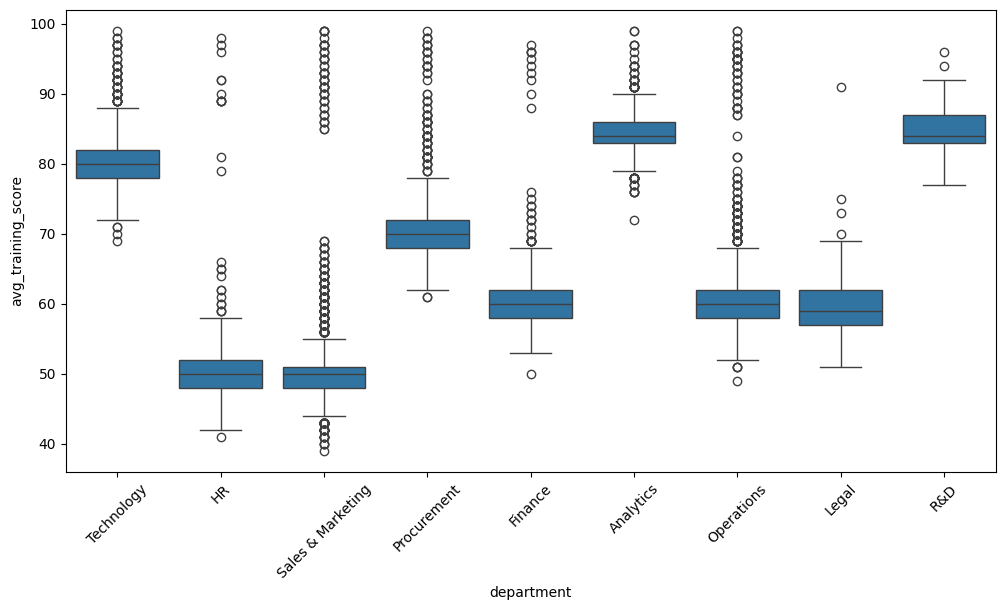

In [41]:
#Identify highest and lowest-performing departments.
plt.figure(figsize=(12,6))

sns.boxplot(
x='department',
y='avg_training_score',
data=df
)

plt.xticks(rotation=45)

plt.show()

## Interpretation

#### Departments with low scores may need specialized training interventions.

# Education vs Length of Service

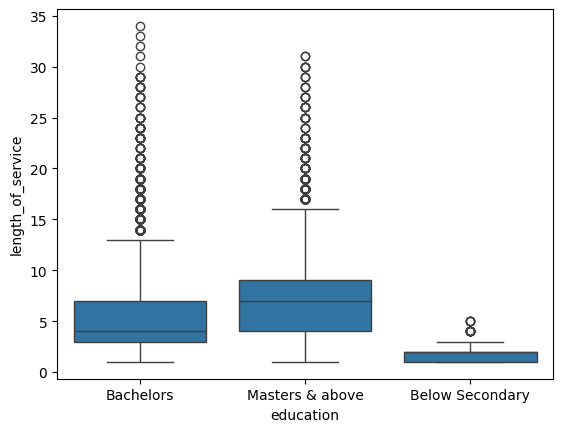

In [42]:
#Compare tenure across education groups.
sns.boxplot(
x='education',
y='length_of_service',
data=df
)

plt.show()

## Interpretation

#### Higher education levels often correlate with longer service periods.

# Age vs Length of Service

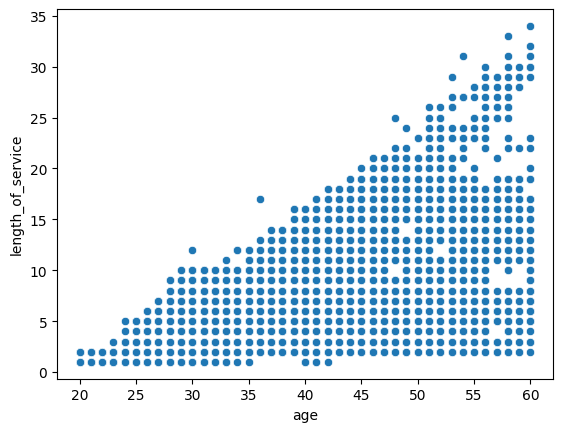

In [43]:
sns.scatterplot(
x='age',
y='length_of_service',
data=df
)

plt.show()

## Interpretation
#### Older employees tend to have accumulated longer service periods.

# Training Score vs KPI Achievement

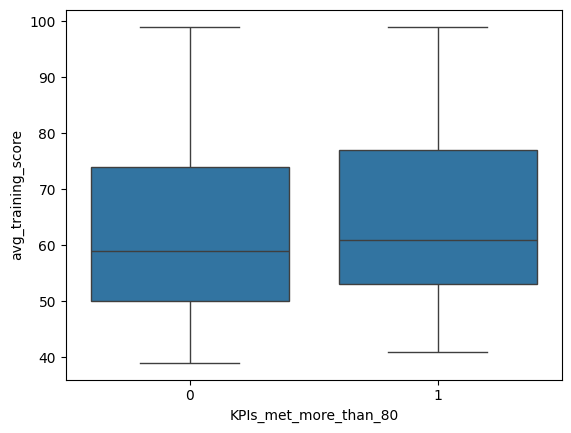

In [44]:
#Compare scores of KPI achievers and non-achievers.
sns.boxplot(
x='KPIs_met_more_than_80',
y='avg_training_score',
data=df
)

plt.show()

## Interpretation
#### Higher training scores among KPI achievers suggest training effectiveness.

# Correlation Heatmap

## Focus on correlations between:

#### .Training Score
#### .KPI Achievement
#### .Awards
#### .Ratings
#### .Length of Service

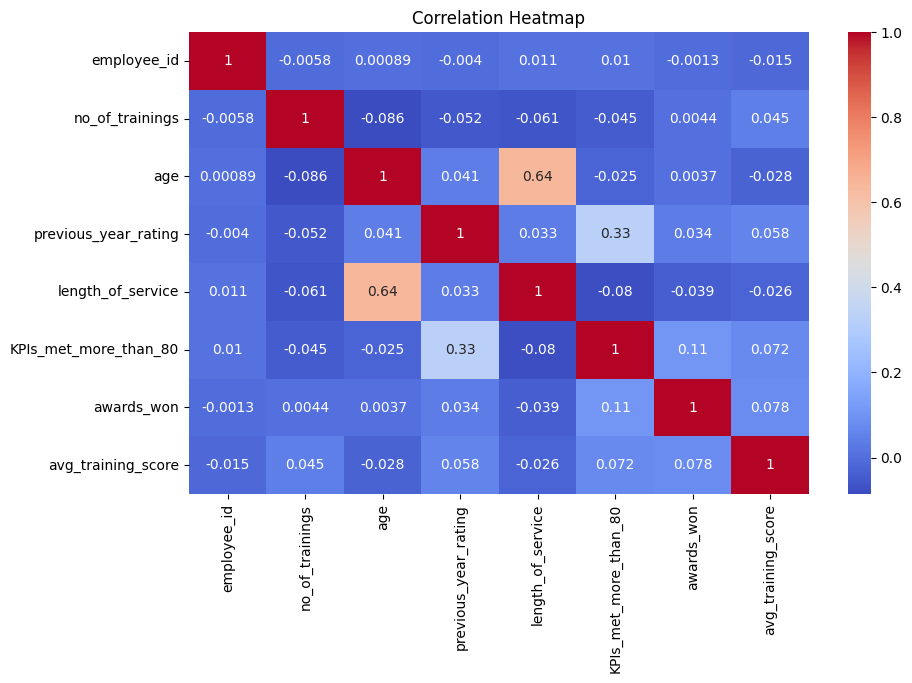

In [45]:
plt.figure(figsize=(10,6))

sns.heatmap(
df.corr(numeric_only=True),
annot=True,
cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

## Interpretation

#### Variables with stronger correlations are important drivers of performance and retention.

# Awards Won vs Training Score

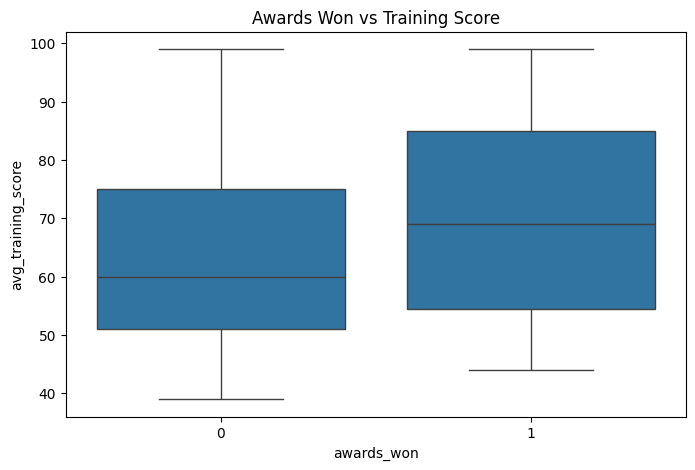

In [46]:
#Compares training scores between award winners and non-winners.
plt.figure(figsize=(8,5))

sns.boxplot(
    x='awards_won',
    y='avg_training_score',
    data=df
)

plt.title('Awards Won vs Training Score')

plt.show()

#### Training effectiveness may influence employee recognition.

# Length of Service vs Training Score

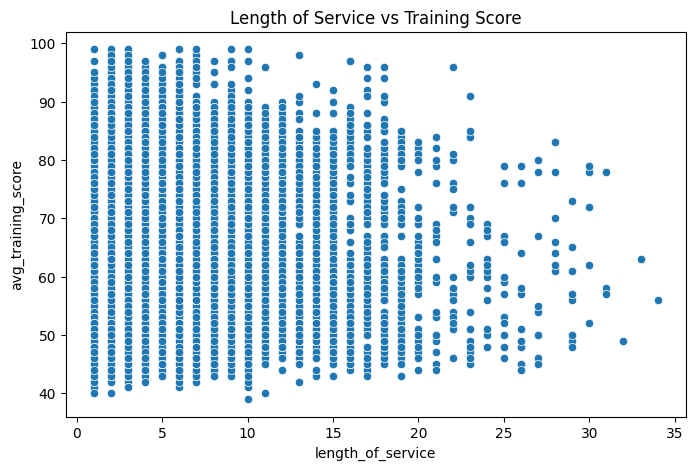

In [47]:
#Shows relationship between tenure and training performance.
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='length_of_service',
    y='avg_training_score',
    data=df
)

plt.title('Length of Service vs Training Score')

plt.show()

## Interpretation

#### Training success is not solely dependent on experience.

# Previous Year Rating vs Training Score

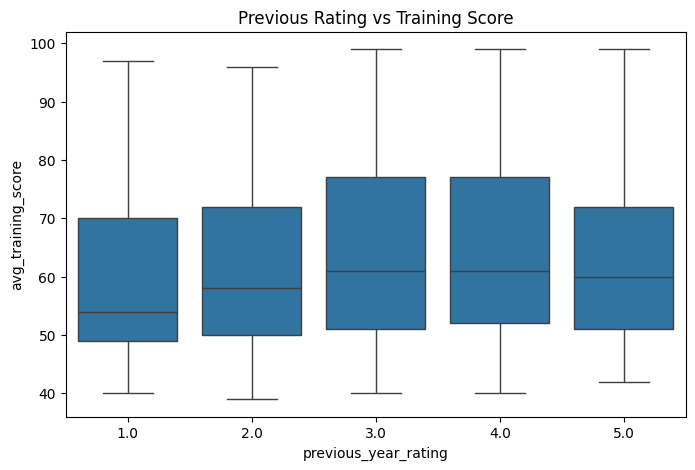

In [48]:
#Shows how training scores vary across performance ratings
plt.figure(figsize=(8,5))

sns.boxplot(
    x='previous_year_rating',
    y='avg_training_score',
    data=df
)

plt.title('Previous Rating vs Training Score')

plt.show()

# Multivariate Analysis

# Department + KPI Achievement + Training Score

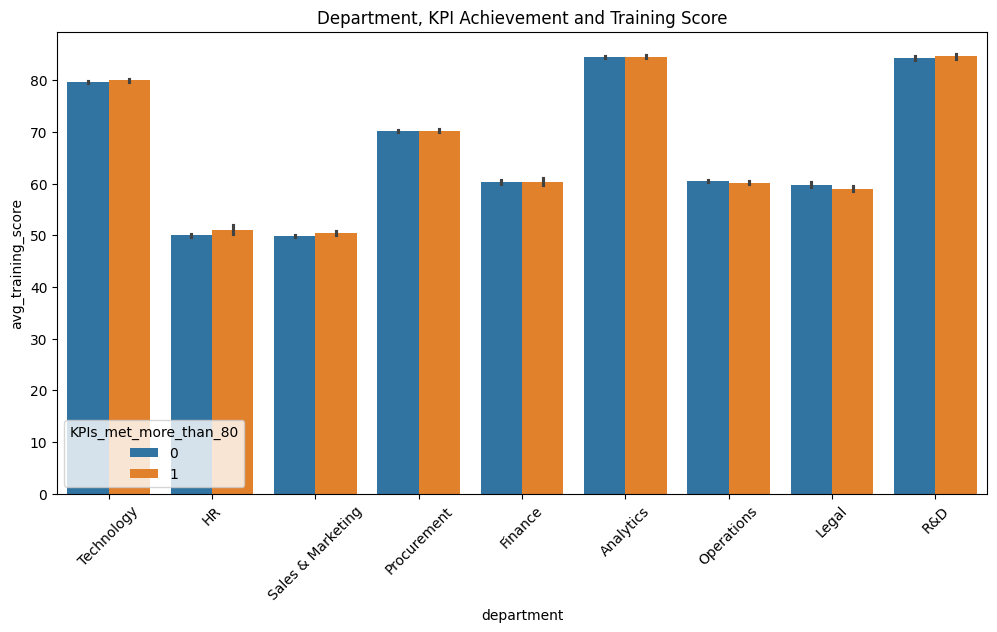

In [49]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='department',
    y='avg_training_score',
    hue='KPIs_met_more_than_80',
    data=df
)

plt.xticks(rotation=45)
plt.title('Department, KPI Achievement and Training Score')

plt.show()

#### Interpretation
#### Departments with higher training scores and KPI achievement indicate strong performance culture.
#### Departments with low training scores and low KPI achievement need intervention.

# Education + Length of Service + Training Score

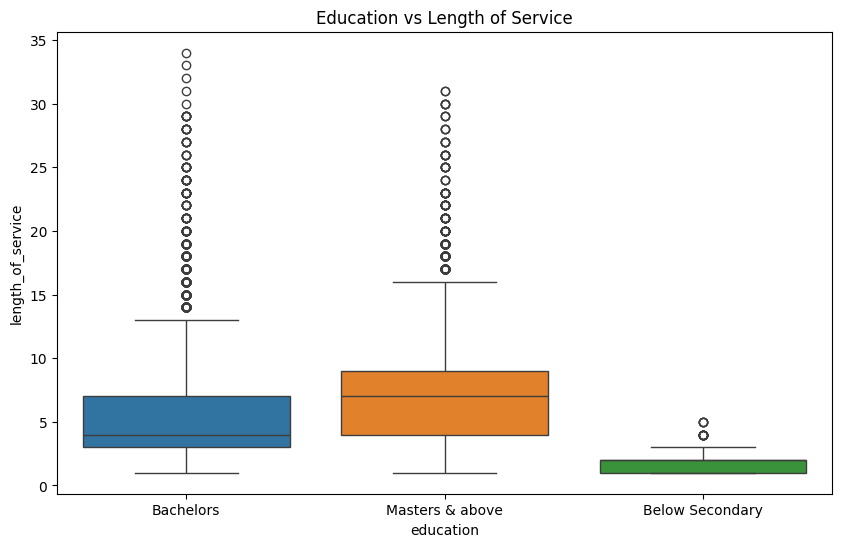

In [50]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='education',
    y='length_of_service',
    hue='education',
    data=df
)

plt.title('Education vs Length of Service')

plt.show()

<Axes: xlabel='education', ylabel='avg_training_score'>

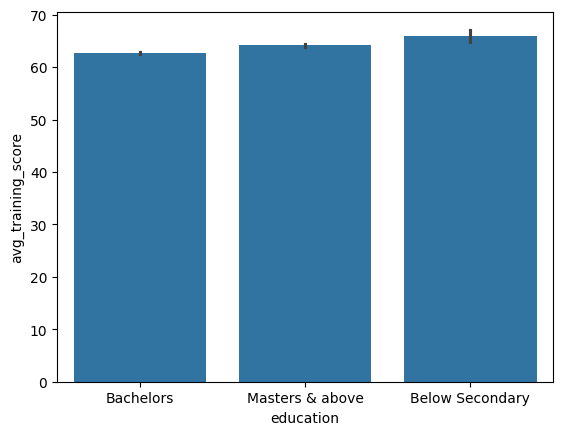

In [51]:
sns.barplot(
    x='education',
    y='avg_training_score',
    data=df
)

# Age + Previous Year Rating + Training Score


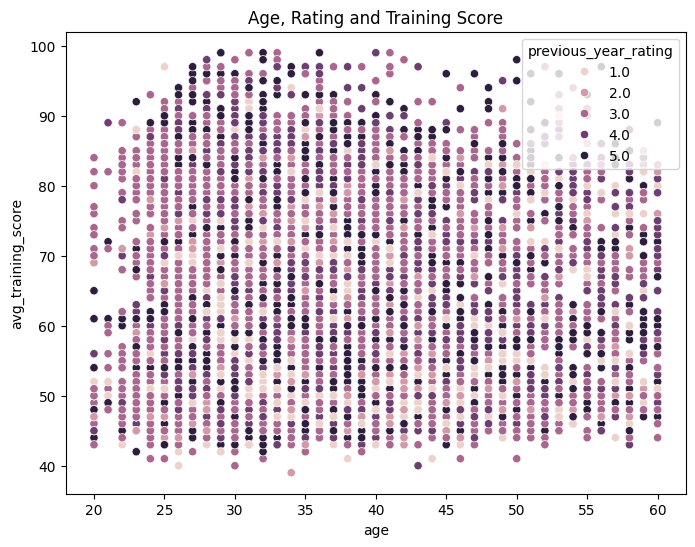

In [52]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='age',
    y='avg_training_score',
    hue='previous_year_rating',
    data=df
)

plt.title('Age, Rating and Training Score')

plt.show()

## Identifies whether high-rated employees consistently perform well in training across age groups.

# Awards Won + KPI Achievement + Training Score

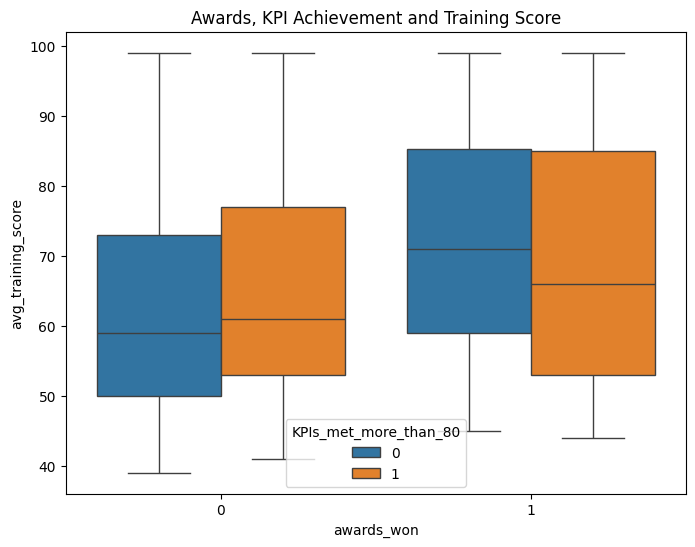

In [53]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='awards_won',
    y='avg_training_score',
    hue='KPIs_met_more_than_80',
    data=df
)

plt.title('Awards, KPI Achievement and Training Score')

plt.show()

## Interpretation
#### Employees receiving awards and meeting KPIs are likely high-value employees.
#### Helps HR identify future leaders.

# Key Metrics Analysis

In [54]:
df['length_of_service'].describe()

count    17415.000000
mean         5.801493
std          4.175632
min          1.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         34.000000
Name: length_of_service, dtype: float64

In [55]:
df['avg_training_score'].describe()

count    17415.000000
mean        63.177720
std         13.418314
min         39.000000
25%         51.000000
50%         60.000000
75%         75.000000
max         99.000000
Name: avg_training_score, dtype: float64

In [56]:
df['awards_won'].value_counts(normalize=True)*100

awards_won
0    97.662934
1     2.337066
Name: proportion, dtype: float64

In [57]:
df['previous_year_rating'].value_counts()

previous_year_rating
3.0    7176
5.0    3817
4.0    3156
1.0    1974
2.0    1292
Name: count, dtype: int64

In [58]:
df['KPIs_met_more_than_80'].value_counts(normalize=True)*100

KPIs_met_more_than_80
0    64.111398
1    35.888602
Name: proportion, dtype: float64

# Retention Trends Analysis

# Age vs Retention

In [59]:
df.groupby(pd.cut(df['age'], bins=[20,30,40,50,60]))['length_of_service'].mean()

C:\Users\golla\AppData\Local\Temp\ipykernel_4072\2912605886.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['age'], bins=[20,30,40,50,60]))['length_of_service'].mean()


age
(20, 30]     3.015837
(30, 40]     5.973854
(40, 50]     9.373080
(50, 60]    12.177419
Name: length_of_service, dtype: float64

# Education vs Retention

In [60]:
df.groupby('education')['length_of_service'].mean()

education
Bachelors          5.276286
Below Secondary    1.762238
Masters & above    7.373270
Name: length_of_service, dtype: float64

# Department vs Retention

In [61]:
df.groupby('department')['length_of_service'].mean()

department
Analytics            4.998232
Finance              5.009975
HR                   5.629362
Legal                4.500000
Operations           6.429342
Procurement          6.187500
R&D                  4.798193
Sales & Marketing    5.753023
Technology           5.844020
Name: length_of_service, dtype: float64

# Training vs Retention

In [62]:
df[['avg_training_score','length_of_service']].corr()

,avg_training_score,length_of_service
avg_training_score,1.000000,-0.026343
length_of_service,-0.026343,1.000000


# Identify High-Performing Employees

In [63]:
high_performers = df[
    (df['KPIs_met_more_than_80'] == 1) &
    (df['previous_year_rating'] >= 4) &
    (df['avg_training_score'] >= df['avg_training_score'].mean())
]

print("Number of High Performers:", len(high_performers))

high_performers.head()

Number of High Performers: 1579


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
9,76303,Technology,region_22,Bachelors,m,sourcing,1,29,5.0,2,1,0,76
40,41432,Analytics,region_26,Bachelors,m,sourcing,1,26,5.0,4,1,0,90
42,39973,Operations,region_13,Bachelors,m,other,1,34,5.0,5,1,0,66
65,57989,Procurement,region_2,Bachelors,m,other,1,29,5.0,2,1,0,74
68,65975,Analytics,region_29,Bachelors,m,other,2,28,5.0,4,1,0,84


In [64]:
high_performers[['age',
                 'length_of_service',
                 'avg_training_score',
                 'previous_year_rating']].describe()

,age,length_of_service,avg_training_score,previous_year_rating
count,1579.000000,1579.000000,1579.000000,1579.000000
mean,35.127296,5.873971,78.051932,4.600380
std,7.654096,3.913507,7.934369,0.489975
min,20.000000,1.000000,64.000000,4.000000
25%,30.000000,3.000000,71.000000,4.000000
50%,33.000000,5.000000,79.000000,5.000000
75%,38.000000,7.000000,84.000000,5.000000
max,60.000000,30.000000,99.000000,5.000000


# Identify Employees at Retention Risk

In [65]:
retention_risk = df[
    (df['KPIs_met_more_than_80'] == 0) &
    (df['awards_won'] == 0) &
    (df['avg_training_score'] < df['avg_training_score'].median())
]

print("Employees at Retention Risk:", len(retention_risk))

retention_risk.head()

Employees at Retention Risk: 5594


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
1,74430,HR,region_4,Bachelors,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1.0,4,0,0,47
11,42639,Sales & Marketing,region_17,Masters & above,m,sourcing,1,40,3.0,10,0,0,46
12,30963,Sales & Marketing,region_4,Masters & above,f,other,1,34,3.0,4,0,0,52
16,27561,Operations,region_27,Bachelors,f,sourcing,1,26,5.0,3,0,0,56


In [66]:
retention_risk[['age',
                'length_of_service',
                'avg_training_score',
                'previous_year_rating']].describe()

,age,length_of_service,avg_training_score,previous_year_rating
count,5594.000000,5594.000000,5594.000000,5594.000000
mean,34.777976,6.010189,51.259385,2.972113
std,7.798626,4.387343,4.180674,1.241286
min,20.000000,1.000000,39.000000,1.000000
25%,29.000000,3.000000,48.000000,2.000000
50%,33.000000,5.000000,50.000000,3.000000
75%,39.000000,8.000000,54.000000,4.000000
max,60.000000,34.000000,59.000000,5.000000


# High Retention Employee Group

In [67]:
high_retention = df[
    df['length_of_service'] >
    df['length_of_service'].mean()
]

print("High Retention Employees:", len(high_retention))

high_retention.head()

High Retention Employees: 7498


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
3,38562,Procurement,region_2,Bachelors,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61
8,66174,Technology,region_7,Masters & above,m,other,1,51,4.0,11,0,0,75
10,60245,Sales & Marketing,region_16,Bachelors,m,sourcing,2,40,5.0,12,1,0,50
11,42639,Sales & Marketing,region_17,Masters & above,m,sourcing,1,40,3.0,10,0,0,46


In [ ]:
high_retention['education'].value_counts() #Education levels

education
Bachelors          4623
Masters & above    2875
Name: count, dtype: int64

In [ ]:
high_retention['department'].value_counts() #departments

department
Sales & Marketing    2326
Operations           1746
Procurement          1040
Technology            913
Analytics             615
HR                    338
Finance               307
R&D                   115
Legal                  98
Name: count, dtype: int64

# Compare High Performers vs Retention Risk

In [70]:
comparison = pd.DataFrame({
    'High Performers': [
        len(high_performers)
    ],
    'Retention Risk': [
        len(retention_risk)
    ]
})

comparison

,High Performers,Retention Risk
0,1579,5594


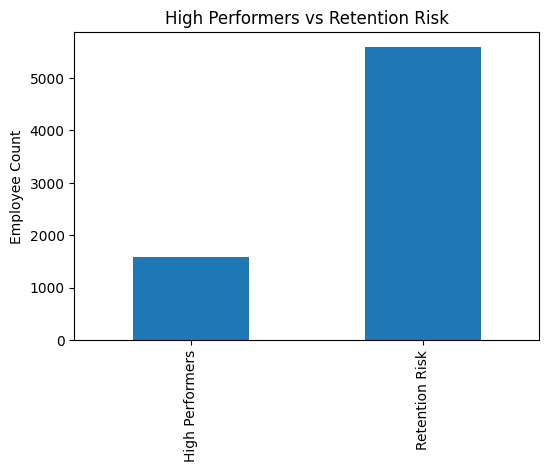

In [71]:
comparison.T.plot(
    kind='bar',
    legend=False,
    figsize=(6,4)
)

plt.title("High Performers vs Retention Risk")
plt.ylabel("Employee Count")

plt.show()

# Department Risk Analysis

In [72]:
#Average KPI Achievement by Department
dept_kpi = df.groupby('department')[
    'KPIs_met_more_than_80'
].mean().sort_values()

dept_kpi

department
Sales & Marketing    0.277208
Legal                0.355422
Technology           0.356071
HR                   0.361011
Procurement          0.373214
Finance              0.397756
Analytics            0.400118
Operations           0.440692
R&D                  0.448795
Name: KPIs_met_more_than_80, dtype: float64

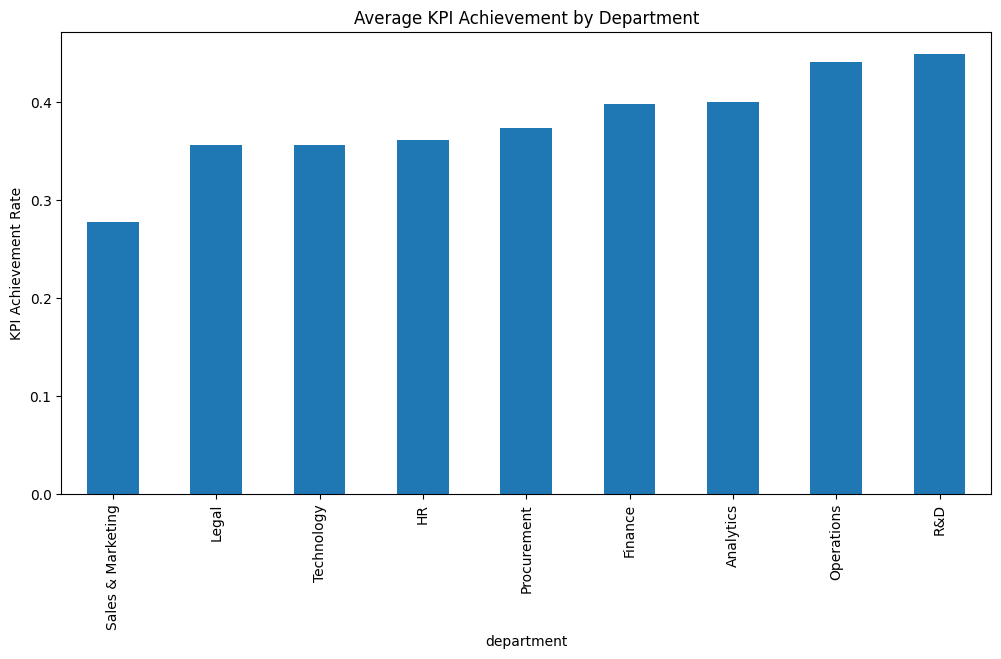

In [73]:
plt.figure(figsize=(12,6))

dept_kpi.plot(
    kind='bar'
)

plt.title("Average KPI Achievement by Department")
plt.ylabel("KPI Achievement Rate")

plt.show()

# Training Score vs KPI Achievement

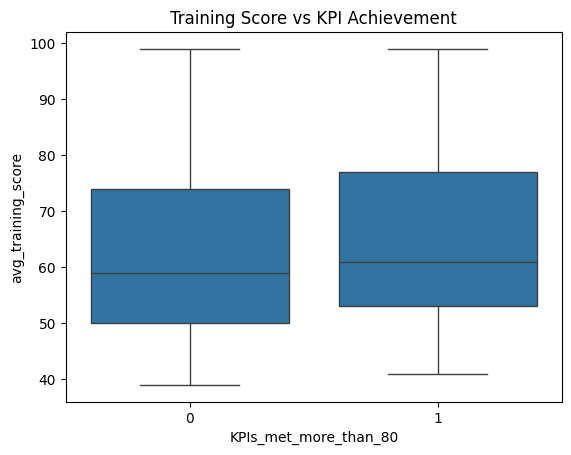

In [74]:
sns.boxplot(
    x='KPIs_met_more_than_80',
    y='avg_training_score',
    data=df
)

plt.title("Training Score vs KPI Achievement")

plt.show()

#### Shows whether employees with better training outcomes are more likely to meet KPI targets.

# Awards vs Performance Rating

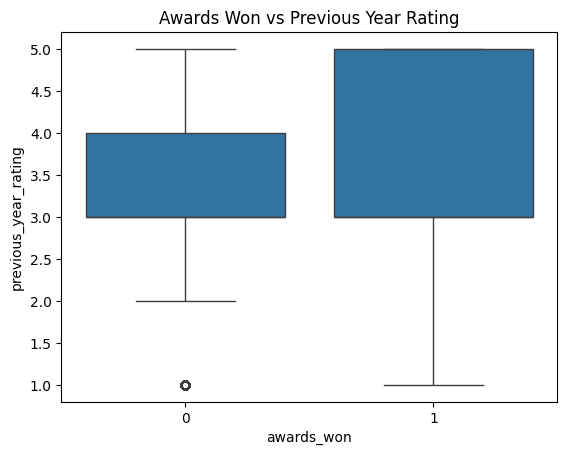

In [75]:
sns.boxplot(
    x='awards_won',
    y='previous_year_rating',
    data=df
)

plt.title("Awards Won vs Previous Year Rating")

plt.show()

# Employee Segmentation

In [76]:
conditions = [
    (df['KPIs_met_more_than_80']==1) &
    (df['awards_won']==1),

    (df['KPIs_met_more_than_80']==1) &
    (df['awards_won']==0),

    (df['KPIs_met_more_than_80']==0)
]

categories = [
    'Star Employee',
    'Good Performer',
    'Needs Improvement'
]

df['employee_segment'] = np.select(
    conditions,
    categories,
    default='Average Performer'
)

df['employee_segment'].value_counts()

employee_segment
Needs Improvement    11165
Good Performer        5971
Star Employee          279
Name: count, dtype: int64

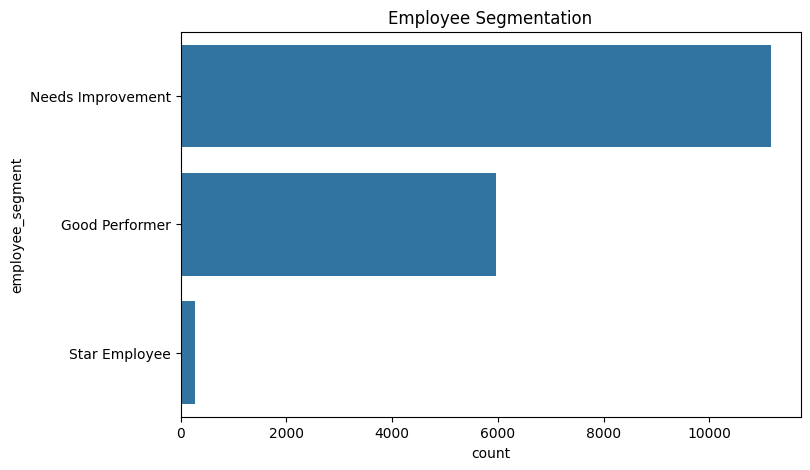

In [77]:
plt.figure(figsize=(8,5))

sns.countplot(
    y='employee_segment',
    data=df,
    order=df['employee_segment'].value_counts().index
)

plt.title("Employee Segmentation")

plt.show()

# Training Improvement Recommendation

In [78]:
dept_training = df.groupby('department')['avg_training_score'].mean().sort_values()

print(dept_training)

department
Sales & Marketing    50.056614
HR                   50.386282
Legal                59.533133
Finance              60.326683
Operations           60.351589
Procurement          70.180357
Technology           79.847658
R&D                  84.451807
Analytics            84.565115
Name: avg_training_score, dtype: float64


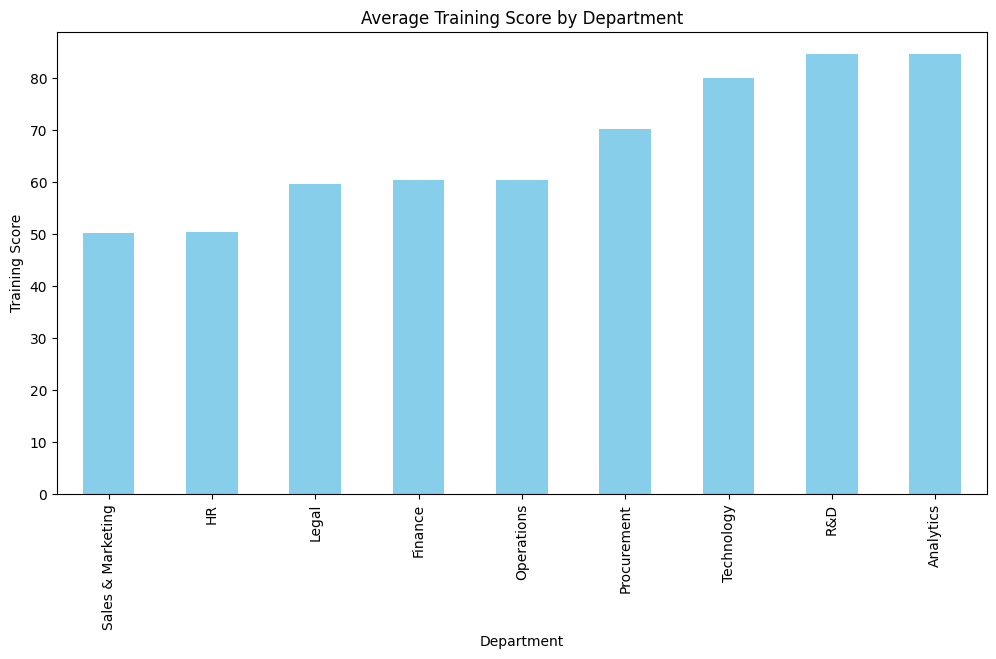

In [79]:
plt.figure(figsize=(12,6))

dept_training.plot(
    kind='bar',
    color='skyblue'
)

plt.title('Average Training Score by Department')
plt.ylabel('Training Score')
plt.xlabel('Department')

plt.show()

## Recommendation

#### Departments with the lowest training scores should receive additional training programs.

# KPI Improvement Recommendation

In [80]:
kpi_percent = (
    df['KPIs_met_more_than_80']
    .value_counts(normalize=True)
    * 100
)

print(kpi_percent)

KPIs_met_more_than_80
0    64.111398
1    35.888602
Name: proportion, dtype: float64


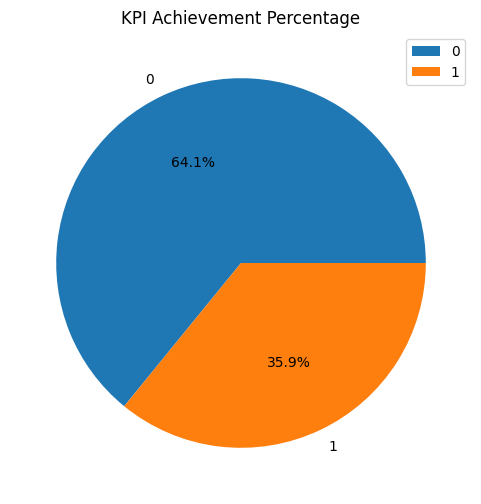

In [82]:
plt.figure(figsize=(6,6))

df['KPIs_met_more_than_80'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('KPI Achievement Percentage')
plt.ylabel('')
plt.legend()
plt.show()

## Recommendation

#### Provide coaching and mentoring for employees who are not meeting KPI targets.

# Recognition Program Recommendation

In [83]:
award_percent = (
    df['awards_won']
    .value_counts(normalize=True)
    * 100
)

print(award_percent)

awards_won
0    97.662934
1     2.337066
Name: proportion, dtype: float64


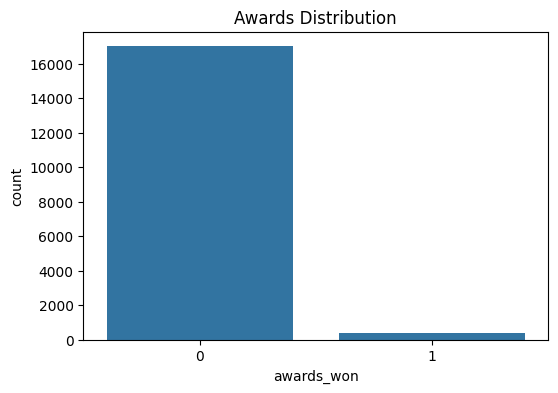

In [84]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='awards_won',
    data=df
)

plt.title('Awards Distribution')

plt.show()

## Recommendation

#### Increase employee recognition initiatives if award participation is low.

# Retention Strategy Recommendation

In [85]:
edu_retention = (
    df.groupby('education')
    ['length_of_service']
    .mean()
    .sort_values(ascending=False)
)

print(edu_retention)

education
Masters & above    7.373270
Bachelors          5.276286
Below Secondary    1.762238
Name: length_of_service, dtype: float64


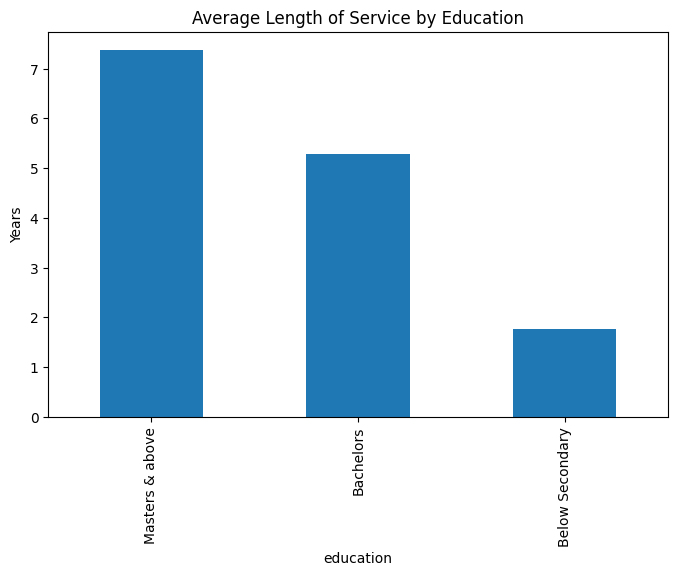

In [86]:
plt.figure(figsize=(8,5))

edu_retention.plot(
    kind='bar'
)

plt.title('Average Length of Service by Education')
plt.ylabel('Years')

plt.show()

## Recommendation

#### Develop career progression plans for highly educated employees to retain talent.

# Department-wise Retention Recommendation

In [87]:
dept_retention = (
    df.groupby('department')
    ['length_of_service']
    .mean()
    .sort_values()
)

print(dept_retention)

department
Legal                4.500000
R&D                  4.798193
Analytics            4.998232
Finance              5.009975
HR                   5.629362
Sales & Marketing    5.753023
Technology           5.844020
Procurement          6.187500
Operations           6.429342
Name: length_of_service, dtype: float64


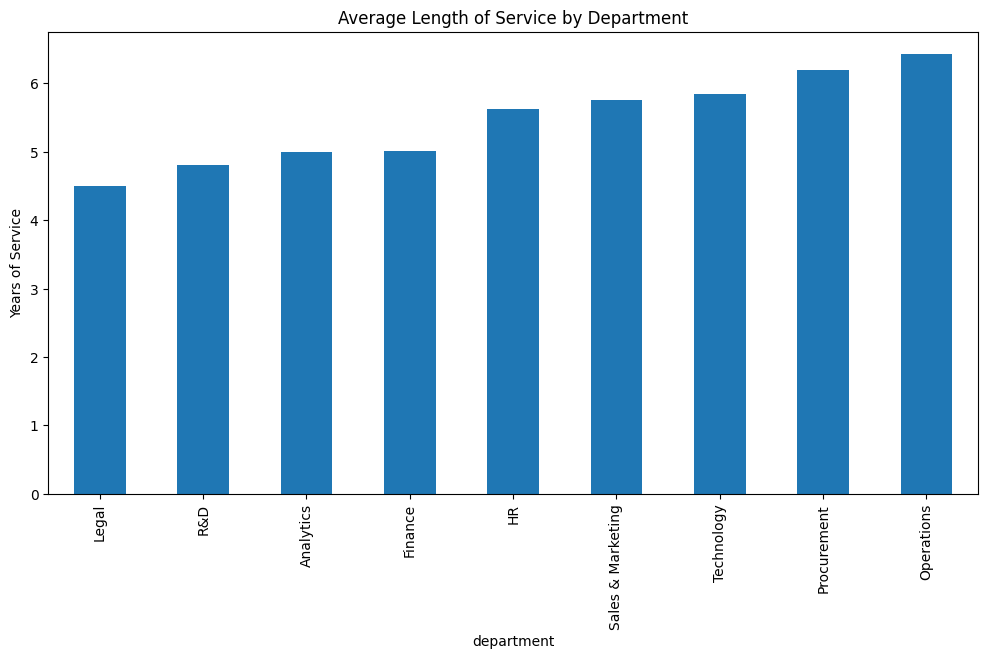

In [88]:
plt.figure(figsize=(12,6))

dept_retention.plot(
    kind='bar'
)

plt.title('Average Length of Service by Department')
plt.ylabel('Years of Service')

plt.show()

## Recommendation

### Departments with lower average tenure should receive targeted retention programs.

# High Performer Retention Recommendation

In [89]:
high_performers = df[
    (df['KPIs_met_more_than_80'] == 1) &
    (df['previous_year_rating'] >= 4)
]

print(high_performers.shape)

(3701, 14)


In [90]:
high_performers['department'].value_counts()

department
Operations           1003
Sales & Marketing     816
Procurement           488
Technology            446
Analytics             391
Finance               202
HR                    183
R&D                   106
Legal                  66
Name: count, dtype: int64

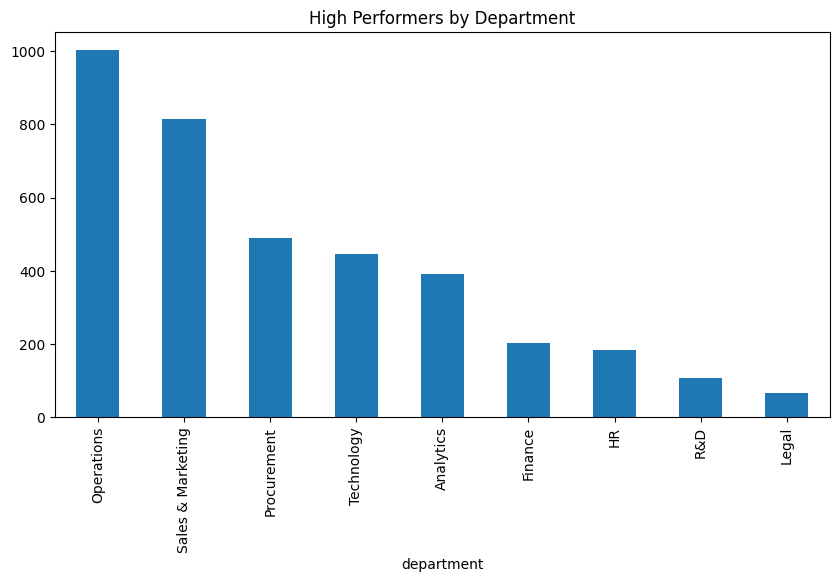

In [91]:
plt.figure(figsize=(10,5))

high_performers['department'].value_counts().plot(
    kind='bar'
)

plt.title('High Performers by Department')

plt.show()

## Recommendation

### Create leadership and promotion opportunities for high-performing employees.

# Employee Segmentation Recommendation

In [92]:
conditions = [
    (df['KPIs_met_more_than_80']==1) &
    (df['awards_won']==1),

    (df['KPIs_met_more_than_80']==1) &
    (df['awards_won']==0),

    (df['KPIs_met_more_than_80']==0)
]

categories = [
    'Star Employee',
    'Good Performer',
    'Needs Improvement'
]

df['employee_segment'] = np.select(
    conditions,
    categories,
    default='Average Performer'
)

df['employee_segment'].value_counts()

employee_segment
Needs Improvement    11165
Good Performer        5971
Star Employee          279
Name: count, dtype: int64

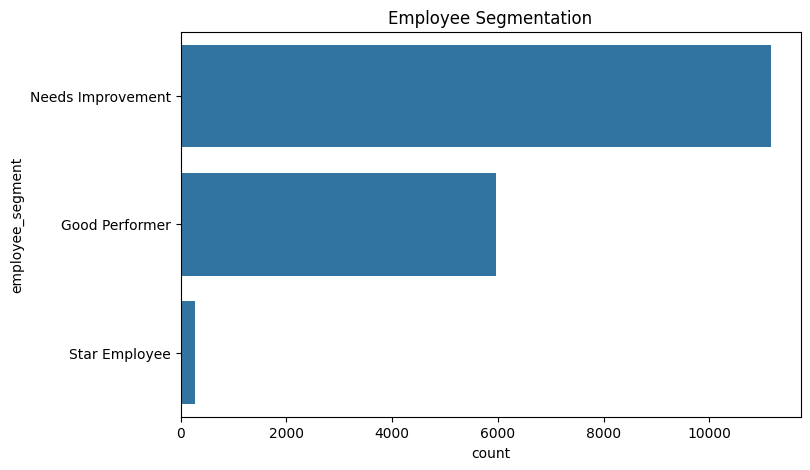

In [93]:
plt.figure(figsize=(8,5))

sns.countplot(
    y='employee_segment',
    data=df,
    order=df['employee_segment'].value_counts().index
)

plt.title('Employee Segmentation')

plt.show()

## Recommendation

#### Use targeted HR strategies for each employee segment:

#### Star Employees → Retention & Leadership
#### Good Performers → Development
#### Average Performers → Upskilling
#### Needs Improvement → Coaching

# Key Findings

In [94]:
summary = pd.DataFrame({
    'Metric': [
        'Total Employees',
        'Average Age',
        'Average Length of Service',
        'Average Training Score'
    ],
    'Value': [
        len(df),
        round(df['age'].mean(),2),
        round(df['length_of_service'].mean(),2),
        round(df['avg_training_score'].mean(),2)
    ]
})

summary

,Metric,Value
0,Total Employees,17415.00
1,Average Age,34.81
2,Average Length of Service,5.80
3,Average Training Score,63.18


# KPI Achievement Summary

In [95]:
kpi_summary = (
    df['KPIs_met_more_than_80']
    .value_counts(normalize=True)
    * 100
)

print(kpi_summary)

KPIs_met_more_than_80
0    64.111398
1    35.888602
Name: proportion, dtype: float64


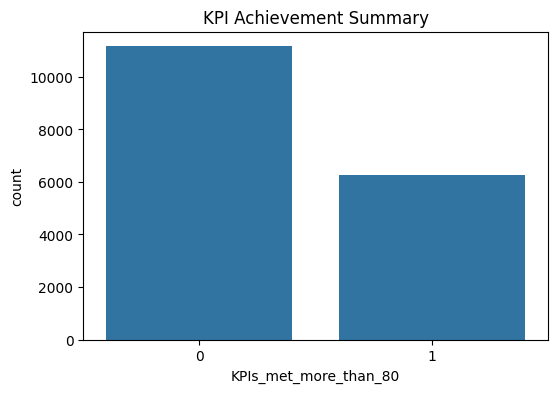

In [96]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='KPIs_met_more_than_80',
    data=df
)

plt.title("KPI Achievement Summary")
plt.show()

# Awards Summary

In [97]:
award_summary = (
    df['awards_won']
    .value_counts(normalize=True)
    * 100
)

print(award_summary)

awards_won
0    97.662934
1     2.337066
Name: proportion, dtype: float64


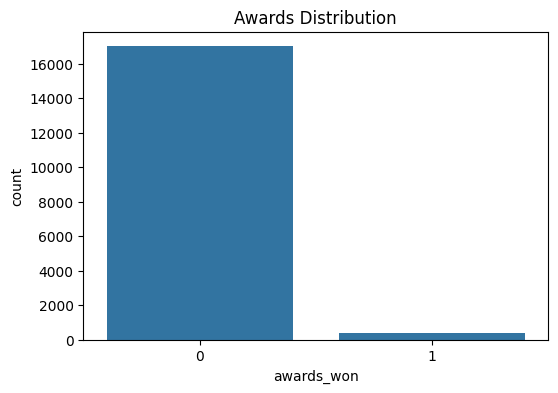

In [98]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='awards_won',
    data=df
)

plt.title("Awards Distribution")
plt.show()

# Top Performing Department

In [99]:
top_departments = (
    df.groupby('department')
    ['avg_training_score']
    .mean()
    .sort_values(ascending=False)
)

print(top_departments)

department
Analytics            84.565115
R&D                  84.451807
Technology           79.847658
Procurement          70.180357
Operations           60.351589
Finance              60.326683
Legal                59.533133
HR                   50.386282
Sales & Marketing    50.056614
Name: avg_training_score, dtype: float64


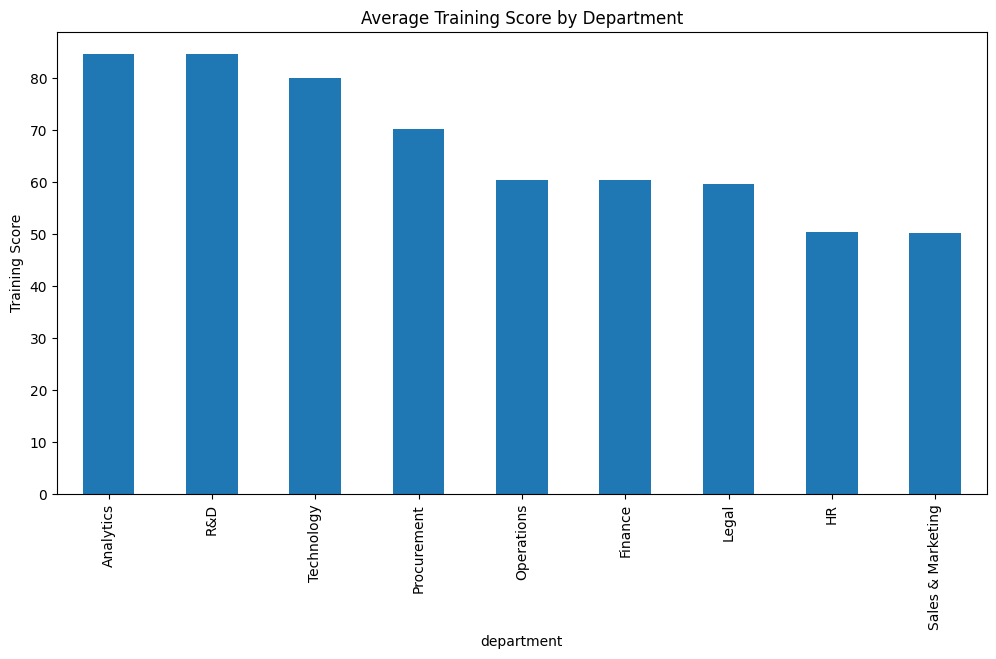

In [100]:
plt.figure(figsize=(12,6))

top_departments.plot(
    kind='bar'
)

plt.title("Average Training Score by Department")
plt.ylabel("Training Score")

plt.show()

# Retention Summary

In [101]:
retention_summary = (
    df.groupby('education')
    ['length_of_service']
    .mean()
)

print(retention_summary)

education
Bachelors          5.276286
Below Secondary    1.762238
Masters & above    7.373270
Name: length_of_service, dtype: float64


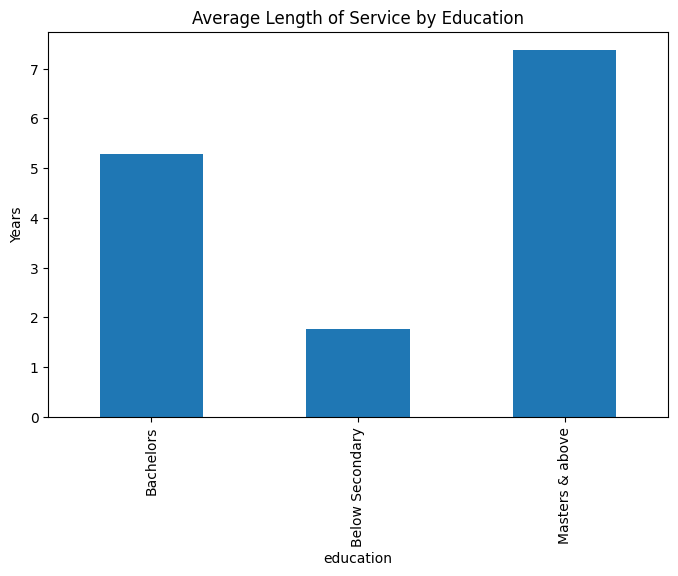

In [102]:
plt.figure(figsize=(8,5))

retention_summary.plot(
    kind='bar'
)

plt.title("Average Length of Service by Education")
plt.ylabel("Years")

plt.show()

# Employee Segmentation Summary

In [103]:
df['employee_segment'].value_counts()

employee_segment
Needs Improvement    11165
Good Performer        5971
Star Employee          279
Name: count, dtype: int64

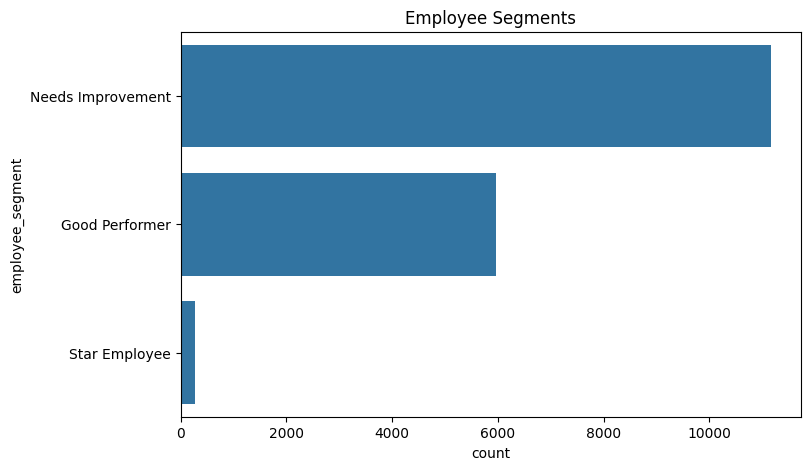

In [104]:
plt.figure(figsize=(8,5))

sns.countplot(
    y='employee_segment',
    data=df,
    order=df['employee_segment'].value_counts().index
)

plt.title("Employee Segments")

plt.show()

# Correlation Summary

In [105]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
employee_id,1.000000,-0.005780,0.000889,-0.004006,0.010660,0.010315,-0.001297,-0.014525
no_of_trainings,-0.005780,1.000000,-0.085722,-0.051966,-0.061179,-0.045065,0.004428,0.045208
age,0.000889,-0.085722,1.000000,0.040965,0.641171,-0.025390,0.003712,-0.028071
previous_year_rating,-0.004006,-0.051966,0.040965,1.000000,0.033051,0.329712,0.034412,0.057812
length_of_service,0.010660,-0.061179,0.641171,0.033051,1.000000,-0.079539,-0.039251,-0.026343
KPIs_met_more_than_80,0.010315,-0.045065,-0.025390,0.329712,-0.079539,1.000000,0.105333,0.071875
awards_won,-0.001297,0.004428,0.003712,0.034412,-0.039251,0.105333,1.000000,0.077690
avg_training_score,-0.014525,0.045208,-0.028071,0.057812,-0.026343,0.071875,0.077690,1.000000


In [106]:
corr_matrix['avg_training_score'].sort_values(ascending=False)

avg_training_score       1.000000
awards_won               0.077690
KPIs_met_more_than_80    0.071875
previous_year_rating     0.057812
no_of_trainings          0.045208
employee_id             -0.014525
length_of_service       -0.026343
age                     -0.028071
Name: avg_training_score, dtype: float64

# Final Dashboard

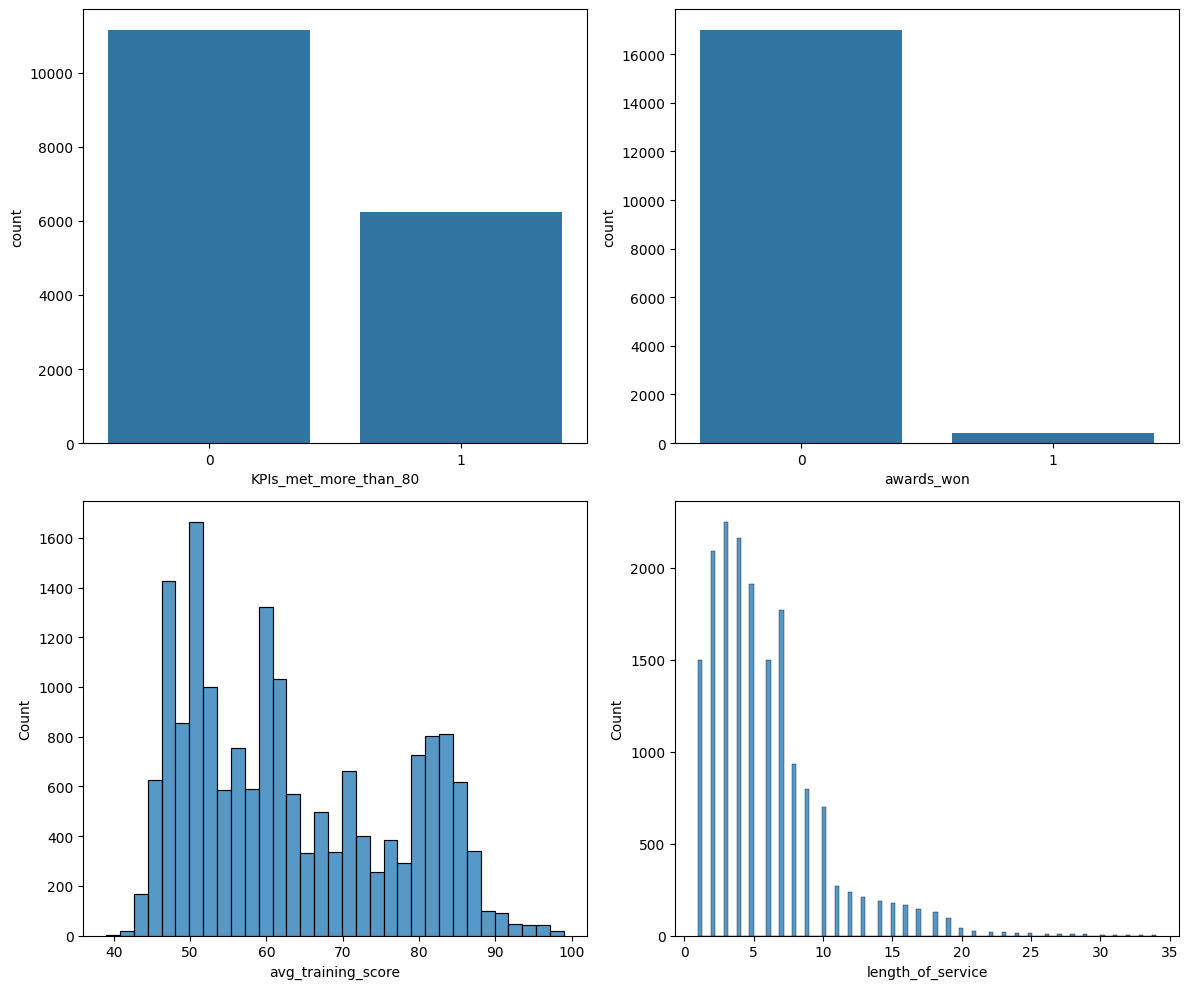

In [107]:
fig, axes = plt.subplots(2,2, figsize=(12,10))

sns.countplot(
    x='KPIs_met_more_than_80',
    data=df,
    ax=axes[0,0]
)

sns.countplot(
    x='awards_won',
    data=df,
    ax=axes[0,1]
)

sns.histplot(
    df['avg_training_score'],
    ax=axes[1,0]
)

sns.histplot(
    df['length_of_service'],
    ax=axes[1,1]
)

plt.tight_layout()
plt.show()

# Conclusion

#### This study analyzed employee performance and retention using demographic, training, and performance-related factors

#### The dataset was cleaned and preprocessed to ensure accurate analysis. Exploratory Data Analysis (EDA) helped identify important patterns and trends within the workforce.

#### The results showed that training scores have a positive impact on employee performance and KPI achievement.


#### Employees with higher previous-year ratings generally performed better in training assessments. Award-winning employees were also found to have stronger performance indicators.

#### Retention analysis revealed that education level, department, and employee engagement influence the length of service. Employees with higher qualifications and better performance records tended to stay longer in the organization.

#### Department-wise analysis highlighted variations in performance and retention across different functional areas. Predictive insights helped identify high-performing employees as well as employees at potential retention risk.

#### The findings emphasize the importance of employee development and recognition programs. Strengthening training initiatives can improve both performance and engagement.

#### Enhanced recognition and career growth opportunities can support long-term retention. Department-specific HR strategies can address performance gaps more effectively.

#### Overall, the analysis provides valuable data-driven insights for improving workforce performance, employee satisfaction, and organizational stability.